In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [7]:
insurance_data = pd.read_csv('insurance.csv')

X = insurance_data.drop(columns=['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({"female" : 1, "male" : 0})
X['smoker'] = X['smoker'].map({"yes" : 1, "no" : 0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha = 0.001:  20922599.871035963
MSE for alpha = 0.1:  20921803.698431373
MSE for alpha = 2:  20908106.779954523
MSE for alpha = 5:  20890881.000633497
MSE for alpha = 10:  20872844.794796683
MSE for alpha = 20:  20877828.53237883
MSE for alpha = 30:  20937537.133939773
MSE for alpha = 40:  21046489.29389078
MSE for alpha = 50:  21196929.86960891
MSE for alpha = 100:  22423172.68602325


<Axes: >

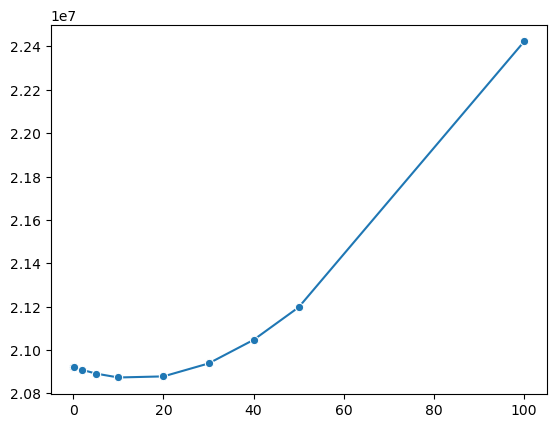

In [18]:
## Apply Lasso regression 

alphas = [0.001, 0.1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    print(f"MSE for alpha = {a}: ", mse)

    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker='o')

In [19]:
## Looking at this graph, we can identify which alpha value is better

# But this is not an optimal way to get the best alpha value, instead we use Cross Validation. It is done in LassoCV

In [23]:
from sklearn.linear_model import LassoCV

a = [0.001, 0.1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("Best Alpha :", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Value :", r2)


Best Alpha : 0.001
MSE : 20922599.871035963
R2 Value : 0.8652317499151699
